In [28]:
import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

torch.manual_seed(0)

device: cpu


Dans ce notebook, on fait un premier test avec le sample détaillé dans l'overleaf pour voir ce que ça donne. Le réseau est entrainé à prédire le bruit ajouté à $Z_0$, ce qui donne $Z_t$ au temps t.

Génération de données synthétiques

In [171]:
mu_x0 = 3.0
var_x0 = 0.4

sigma_base = 1
if sigma_base != 0:
    eps_mean = 3.0 / sigma_base

n_samples = 30000

# "gaussian", "mixture", ou "exponential"
data = "mixture"


# ============================================================
# Paramètres du cas exponentiel
# ============================================================
exponential_rate = 1.0


# ============================================================
# Paramètres du cas gaussien
# ============================================================

mu_z0_gaussian = mu_x0 + sigma_base * eps_mean
var_z0_gaussian = var_x0 + sigma_base**2


# ============================================================
# Paramètres du mélange de gaussiennes
# ============================================================

mixture_weights = torch.tensor(
    [0.7, 0.3],
    device=device,
)

mixture_means = torch.tensor(
    [-4.0, 4],
    device=device,
)

mixture_stds = torch.tensor(
    [0.2, 0.5],
    device=device,
)





def sample_x0_mixture(batch_size):
    """
    X_0 ~ sum_k pi_k N(mu_k, std_k^2).
    """

    comp_ids = torch.multinomial(
        mixture_weights,
        num_samples=batch_size,
        replacement=True,
    )

    means = mixture_means[comp_ids].reshape(batch_size, 1)
    stds = mixture_stds[comp_ids].reshape(batch_size, 1)

    x0 = means + stds * torch.randn(
        batch_size,
        1,
        device=device,
    )

    return x0


def sample_x0_gaussian(batch_size):
    """
    X_0 ~ N(mu_x0, var_x0).
    """

    std_x0 = torch.sqrt(
        torch.tensor(
            var_x0,
            device=device,
        )
    )

    x0 = mu_x0 + std_x0 * torch.randn(
        batch_size,
        1,
        device=device,
    )

    return x0


def sample_x0_exponential(batch_size):
    """
    X_0 ~ Exponential(rate = exponential_rate).

    Support :
        X_0 >= 0.
    """

    distribution = torch.distributions.Exponential(
        rate=torch.tensor(
            exponential_rate,
            device=device,
        )
    )

    x0 = distribution.sample(
        (batch_size,)
    ).reshape(batch_size, 1)

    return x0

def sample_z0_from_x0(x0):
    """
    Modèle d'observation :

        Z_0 = X_0 + sigma_base * epsilon_0

    avec :

        epsilon_0 ~ N(eps_mean, 1).
    """

    eps0 = eps_mean + torch.randn_like(x0)

    z0 = x0 + sigma_base * eps0

    return z0


def sample_joint_data(batch_size, data):
    """
    Return both hidden X_0 and observed Z_0.
    """

    if data == "gaussian":
        x0 = sample_x0_gaussian(batch_size)

    elif data == "mixture":
        x0 = sample_x0_mixture(batch_size)

    elif data == "exponential":
        x0 = sample_x0_exponential(batch_size)

    else:
        raise ValueError(
            "data must be 'gaussian', 'mixture', or 'exponential'."
        )

    z0 = sample_z0_from_x0(x0)

    return x0, z0


def sample_data(batch_size, data=data):
    """
    Le DDPM ne voit que Z_0.
    """

    _, z0 = sample_joint_data(
        batch_size,
        data=data,
    )

    return z0

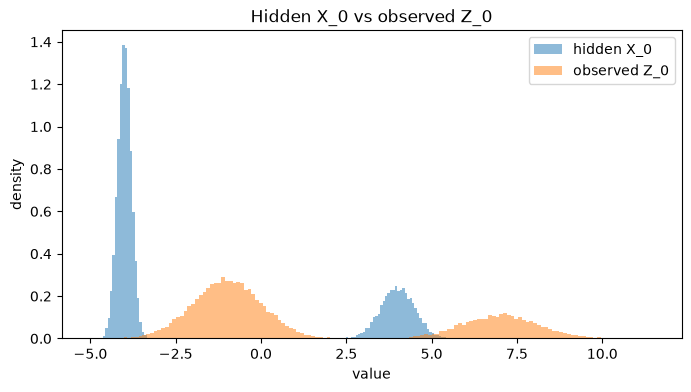

In [172]:
x0, z0 = sample_joint_data(n_samples, data=data)

x0_np = x0.detach().cpu().numpy()
z0_np = z0.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.hist(x0_np, bins=150, density=True, alpha=0.5, label="hidden X_0")
plt.hist(z0_np, bins=150, density=True, alpha=0.5, label="observed Z_0")
plt.title("Hidden X_0 vs observed Z_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

Hyperparamètre et noise schedule

In [173]:
T = 500

beta_start = 6e-3
beta_end = 0.04

betas = torch.linspace(beta_start, beta_end, T, device=device) # Schedule linéaire pour les betas
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def sigma2_at_index(t_index):
    """
    Return sigma_t^2 = sigma_base^2 / 2^t for Python index t.
    t_index shape: (batch_size,)
    """
    return sigma_base**2 * torch.exp(-math.log(2.0) * t_index.float())


def extract_sigma2(t, x_shape):
    """
    Return sigma_t^2 reshaped for broadcasting.
    """
    out = sigma2_at_index(t)
    return out.reshape(-1, *([1] * (len(x_shape) - 1)))

def extract(v, t, x_shape):
    """
    Extract v[t] for each element of the batch, then reshape for broadcasting.

    v: tensor of shape (T,)
       Example: betas, alphas, alpha_bars

    t: tensor of shape (batch_size,)
       Time index for each sample in the batch.

    x_shape: shape of the variable we want to multiply with.
       Example: z.shape = (batch_size, 1)

    Returns:
       tensor of shape (batch_size, 1, ..., 1)
    """
    out = v.gather(0, t)
    return out.view(t.shape[0], *([1] * (len(x_shape) - 1)))

Forward

In [174]:
def q_sample(z0, t, eps=None):
    """
    Sample z_t from q(z_t | z_0).
    """
    if eps is None:
        eps = torch.randn_like(z0)

    alpha_bar_t = extract(alpha_bars, t, z0.shape)

    zt = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1.0 - alpha_bar_t) * eps
    return zt, eps

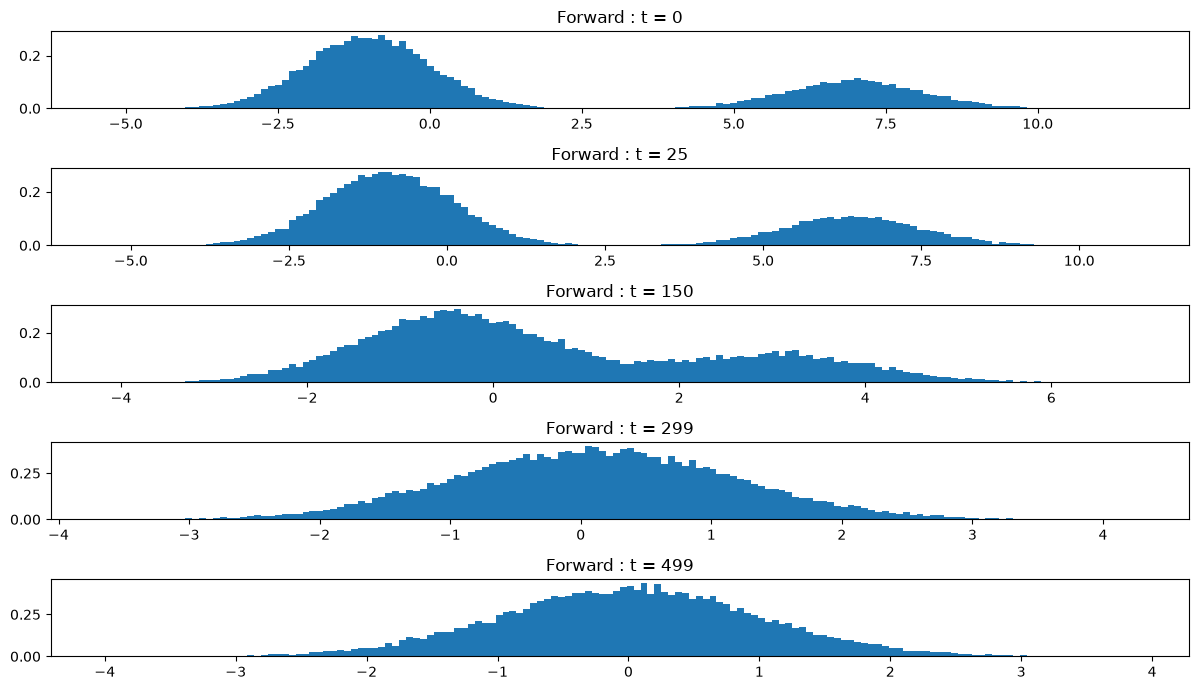

In [175]:
z0 = sample_data(30000, data=data)

times_to_plot = [0, 25, 150, 299, 499]

plt.figure(figsize=(12, 7))

for i, tt in enumerate(times_to_plot):
    t = torch.full((z0.shape[0],), tt, device=device, dtype=torch.long)
    zt, _ = q_sample(z0, t)
    zt_np = zt.detach().cpu().numpy()

    plt.subplot(len(times_to_plot), 1, i + 1)
    plt.hist(zt_np, bins=150, density=True)
    plt.title(f"Forward : t = {tt}")

plt.tight_layout()
plt.show()

Entrainement pour prédire le score

In [176]:

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2

        frequencies = torch.exp(
            -math.log(10000.0)
            * torch.arange(
                half_dim,
                device=t.device,
                dtype=torch.float32,
            )
            / max(half_dim - 1, 1)
        )

        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)

        embedding = torch.cat(
            [
                torch.sin(angles),
                torch.cos(angles),
            ],
            dim=1,
        )

        if self.dim % 2 == 1:
            embedding = F.pad(embedding, (0, 1))

        return embedding


class ScoreModel(nn.Module):
    """
    model(zt, t) retourne directement :

        score_theta(zt, t) ~= d/dz log p_t^Z(zt).

    Le réseau interne apprend la version stable :

        r_theta(zt, t)
        =
        sqrt(1 - alpha_bar_t) * score_theta(zt, t).
    """

    def __init__(
        self,
        alpha_bars,
        time_dim=64,
        hidden_dim=128,
    ):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.register_buffer(
            "score_scales",
            torch.sqrt(
                (1.0 - alpha_bars).clamp_min(1e-8)
            ),
        )

        self.net = nn.Sequential(
            nn.Linear(1 + time_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, 1),
        )

        # Au départ, le score est proche de zéro.
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def normalized_score(self, zt, t):
        """
        Retourne r_theta = sigma_t * score_theta.

        Cette fonction est uniquement utilisée pendant
        l'entraînement pour éviter une division numérique
        par sigma_t.
        """
        t_embedding = self.time_embedding(t)

        inputs = torch.cat(
            [
                zt,
                t_embedding,
            ],
            dim=1,
        )

        return self.net(inputs)

    def forward(self, zt, t):
        """
        Cette sortie est utilisée directement par le sampler.
        """
        normalized_score = self.normalized_score(zt, t)

        sigma_t = extract(
            self.score_scales,
            t,
            zt.shape,
        ).clamp_min(1e-4)

        return normalized_score / sigma_t


model = ScoreModel(alpha_bars).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-6,
)

In [177]:
def sample_training_timesteps(batch_size):
    """
    Tirage non uniforme des temps.

    - 75 % : très concentré vers les petits temps.
    - 25 % : uniforme sur toute la chaîne.

    Cela donne beaucoup plus de signal aux temps proches
    de t = 0, sans perdre l'apprentissage des grands temps.
    """

    uniform_t = torch.randint(
        low=0,
        high=T,
        size=(batch_size,),
        device=device,
        dtype=torch.long,
    )

    u = torch.rand(
        batch_size,
        device=device,
    )

    early_t = torch.floor(
        T * u.pow(4)
    ).long()

    early_t = early_t.clamp(
        min=0,
        max=T - 1,
    )

    use_early_time = torch.rand(
        batch_size,
        device=device,
    ) < 0.85

    t = torch.where(
        use_early_time,
        early_t,
        uniform_t,
    )

    return t


def train_step(model, optimizer, batch_size):
    model.train()

    z0 = sample_data(
        batch_size,
        data=data,
    )

    t = sample_training_timesteps(batch_size)

    zt, eps = q_sample(z0, t)

    # r_theta = sigma_t * score_theta.
    #
    # Le score conditionnel est :
    #
    # grad_z log q(z_t | z_0) = -eps / sigma_t.
    #
    # Donc r_theta doit apprendre -eps.
    #
    # On évite explicitement tout calcul de -eps / sigma_t.
    normalized_score_prediction = model.normalized_score(
        zt,
        t,
    )

    loss = (
        normalized_score_prediction + eps
    ).square().mean()

    optimizer.zero_grad(set_to_none=True)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0,
    )

    optimizer.step()

    return loss.item()


losses = []

num_steps = 10000
batch_size = 1028

for step in range(num_steps):
    loss = train_step(
        model=model,
        optimizer=optimizer,
        batch_size=batch_size,
    )

    losses.append(loss)

    if (step + 1) % 500 == 0:
        print(
            f"step {step + 1:5d}"
            f" | loss = {loss:.6f}"
        )

step   500 | loss = 0.788339
step  1000 | loss = 0.645519
step  1500 | loss = 0.706994
step  2000 | loss = 0.669308
step  2500 | loss = 0.656126
step  3000 | loss = 0.658713
step  3500 | loss = 0.583858
step  4000 | loss = 0.614122
step  4500 | loss = 0.604575
step  5000 | loss = 0.593333
step  5500 | loss = 0.627740
step  6000 | loss = 0.609557
step  6500 | loss = 0.570372
step  7000 | loss = 0.685865
step  7500 | loss = 0.588737
step  8000 | loss = 0.668988
step  8500 | loss = 0.647987
step  9000 | loss = 0.583643
step  9500 | loss = 0.624803
step 10000 | loss = 0.639972


In [178]:
## Use only to check if the score is well learned
# @torch.no_grad()
# def true_gaussian_score(zt, t):
#     """
#     Vrai score marginal de Z_t dans le cas gaussien.

#     Hypothèses :
#         Z_0 ~ N(mu_z0, var_z0)

#         Z_t = sqrt(alpha_bar_t) Z_0
#               + sqrt(1 - alpha_bar_t) eps

#     Donc :
#         Z_t ~ N(mean_t, var_t)

#     et :
#         grad_z log p_t^Z(z)
#         =
#         -(z - mean_t) / var_t
#     """

#     alpha_bar_t = extract(alpha_bars, t, zt.shape)

#     mean_t = torch.sqrt(alpha_bar_t) * mu_z0

#     var_t = (
#         alpha_bar_t * var_z0
#         + (1.0 - alpha_bar_t)
#     )

#     return -(zt - mean_t) / var_t


# @torch.no_grad()
# def check_scores_gaussian(
#     model,
#     time_steps,
#     n_points=1000,
#     n_std=4.0,
# ):
#     """
#     Compare le score appris au vrai score gaussien
#     pour plusieurs temps entiers.

#     Parameters
#     ----------
#     model : torch.nn.Module
#         Le modèle appris. Il doit retourner directement le score.

#     time_steps : list[int]
#         Liste d'indices Python dans {0, ..., T - 1}.
#         Exemple : [0, 1, 5, 10, 50, 100, T - 1].

#     n_points : int
#         Nombre de points utilisés pour comparer les courbes.

#     n_std : float
#         Intervalle de tracé :
#         [mean_t - n_std * std_t, mean_t + n_std * std_t].
#     """

#     model.eval()

#     time_steps = list(time_steps)

#     for time_step in time_steps:
#         if time_step < 0 or time_step >= T:
#             raise ValueError(
#                 f"time_step doit être dans [0, {T - 1}], "
#                 f"mais vaut {time_step}."
#             )

#     n_cols = 2
#     n_rows = math.ceil(len(time_steps) / n_cols)

#     fig, axes = plt.subplots(
#         n_rows,
#         n_cols,
#         figsize=(12, 4 * n_rows),
#         squeeze=False,
#     )

#     metrics = []

#     for index, time_step in enumerate(time_steps):
#         row = index // n_cols
#         col = index % n_cols

#         ax = axes[row, col]

#         t = torch.full(
#             (n_points,),
#             time_step,
#             device=device,
#             dtype=torch.long,
#         )

#         alpha_bar_value = alpha_bars[time_step]

#         mean_t = torch.sqrt(alpha_bar_value) * mu_z0

#         var_t = (
#             alpha_bar_value * var_z0
#             + (1.0 - alpha_bar_value)
#         )

#         std_t = torch.sqrt(var_t)

#         z_grid = torch.linspace(
#             mean_t - n_std * std_t,
#             mean_t + n_std * std_t,
#             n_points,
#             device=device,
#         ).reshape(-1, 1)

#         learned_score = model(z_grid, t)

#         exact_score = true_gaussian_score(
#             z_grid,
#             t,
#         )

#         error = learned_score - exact_score

#         mse = error.square().mean().item()
#         mae = error.abs().mean().item()
#         max_error = error.abs().max().item()

#         metrics.append(
#             {
#                 "time_step": time_step,
#                 "mean_t": mean_t.item(),
#                 "var_t": var_t.item(),
#                 "mse": mse,
#                 "mae": mae,
#                 "max_abs_error": max_error,
#             }
#         )

#         ax.plot(
#             z_grid.squeeze().cpu().numpy(),
#             exact_score.squeeze().cpu().numpy(),
#             label="true Gaussian score",
#             linewidth=2,
#         )

#         ax.plot(
#             z_grid.squeeze().cpu().numpy(),
#             learned_score.squeeze().cpu().numpy(),
#             label="learned score",
#             linestyle="--",
#             linewidth=2,
#         )

#         ax.set_title(
#             f"time_step = {time_step}\n"
#             f"MSE = {mse:.3e}, MAE = {mae:.3e}"
#         )

#         ax.set_xlabel("z")
#         ax.set_ylabel("score")
#         ax.grid(True, alpha=0.3)
#         ax.legend()

#     for index in range(len(time_steps), n_rows * n_cols):
#         row = index // n_cols
#         col = index % n_cols
#         axes[row, col].axis("off")

#     plt.tight_layout()
#     plt.show()

#     print("\nScore comparison summary")
#     print("-" * 86)
#     print(
#         f"{'t':>6} | "
#         f"{'mean_t':>12} | "
#         f"{'var_t':>12} | "
#         f"{'MSE':>12} | "
#         f"{'MAE':>12} | "
#         f"{'max error':>12}"
#     )
#     print("-" * 86)

#     for result in metrics:
#         print(
#             f"{result['time_step']:6d} | "
#             f"{result['mean_t']:12.6f} | "
#             f"{result['var_t']:12.6f} | "
#             f"{result['mse']:12.3e} | "
#             f"{result['mae']:12.3e} | "
#             f"{result['max_abs_error']:12.3e}"
#         )

#     return metrics

# metrics = check_scores_gaussian(
#     model=model,
#     time_steps=[0, 1, 2, 5, 10, 25, 50, 100, 250, T - 1],
#     n_points=2000,
# )

Sampling

In [179]:
RHO = 0.80
FD_STEP = 0.10

@torch.no_grad()
def p_sample_hidden_x_ddpm(model,zt, t):
    """
    Sample adapted but we use the actual Gaussian score of Z_t, which is known in this synthetic example.
    """

    beta_t = extract(betas, t, zt.shape)
    alpha_t = extract(alphas, t, zt.shape)
    alpha_bar_t = extract(
    alpha_bars,
    t,
    zt.shape,
        )
    # sigma_{t-1}^2
    sigma_prev2 = extract_sigma2(t, zt.shape)
    sigma_prev = torch.sqrt(sigma_prev2)
    # delta_t = beta_t + alpha_t * sigma_{t-1}^2
    delta_t = beta_t + alpha_t * sigma_prev2
    
    # Bias induced by E[epsilon_{t-1}] = eps_mean.
    # Z_t | X_{t-1}=x is N(sqrt(alpha_t)*(x + sigma_{t-1} eps_mean), delta_t I).
    bias_t = torch.sqrt(alpha_t) * sigma_prev * eps_mean

    # Score learned of f_t^Z
    score = model(zt, t)

    h_t = (
    FD_STEP
    * torch.sqrt(
        (1.0 - alpha_bar_t).clamp_min(1e-6)
    )
).clamp_min(0.05)

    # Différence finie centrale : aucune dérivée autograd
    score_plus = model(zt + h_t, t)
    score_minus = model(zt - h_t, t)

    score_derivative = (
        score_plus - score_minus
    ) / (2.0 * h_t)

    # Dérivée amortie : rho fixe
    score_derivative = RHO * score_derivative


    var_x_prev = (
    delta_t / alpha_t
) * (
    1.0 + delta_t * score_derivative
)
    var_x_prev = var_x_prev.clamp_min(1e-8)


    noise_x = torch.randn_like(zt)
    
    # 
    # Tweedie estimate: mean of X_{t-1} | Z_t
    x_prev_hat = (zt -bias_t + delta_t * score) / torch.sqrt(alpha_t)

    #Tweedie variance: var(X_{t-1} | Z_t) = delta_t / alpha_t

    x_prev = x_prev_hat + torch.sqrt(var_x_prev) * noise_x



    noise_z = torch.randn_like(zt)
    z_prev = x_prev + sigma_prev * eps_mean + torch.sqrt(sigma_prev2) * noise_z

    return z_prev, x_prev, x_prev_hat

In [180]:
@torch.no_grad()
def sample_hidden_x_from_z_ddpm( model, n_samples):
    """
    Full adapted reverse chain.

    Returns:
        x0_hat    : generated latent X_0
        z0_hat    : generated observed Z_0
        trajectory: selected intermediate states
    """
  
    zt = torch.randn(n_samples, 1, device=device)

    trajectory = []
    x_prev_hat = None

    for time_step in reversed(range(T)):
        t = torch.full((n_samples,), time_step, device=device, dtype=torch.long)

        z_prev, x_prev, x_prev_hat= p_sample_hidden_x_ddpm(model, zt, t)

        if time_step in [T - 1, 200, 100, 50, 10, 0]:
            trajectory.append(
                {
                    "time": time_step,
                    "z_t": zt.detach().cpu(),
                    "x_prev": x_prev.detach().cpu(),
                    "x_prev_hat": x_prev_hat.detach().cpu(),
                    "z_prev": z_prev.detach().cpu(),
                }
            )

        zt = z_prev

    z0_hat = zt.detach().cpu()
    x0_hat = x_prev.detach().cpu()

    return x0_hat, z0_hat, trajectory

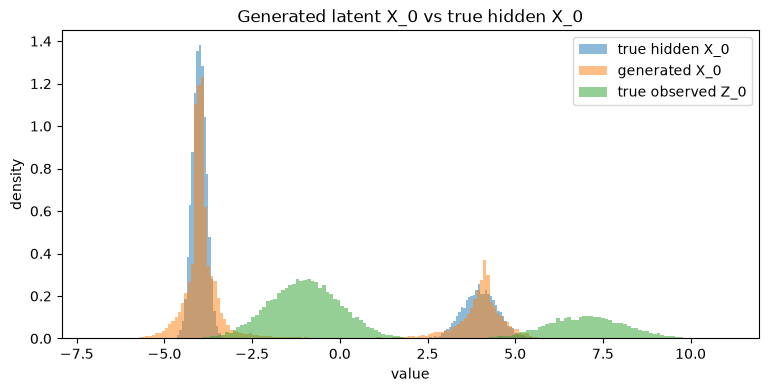

In [181]:

x0_gen, z0_gen, trajectory = sample_hidden_x_from_z_ddpm(model, n_samples=30000)

x0_real, z0_real = sample_joint_data(30000, data=data)
x0_real = x0_real.detach().cpu()
z0_real = z0_real.detach().cpu()

plt.figure(figsize=(9, 4))
plt.hist(x0_real.numpy(), bins=150, density=True, alpha=0.5, label="true hidden X_0")
plt.hist(x0_gen.numpy(), bins=150, density=True, alpha=0.5, label="generated X_0")
plt.hist(z0_real.numpy(), bins=150, density=True, alpha=0.5, label="true observed Z_0")
plt.title("Generated latent X_0 vs true hidden X_0")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()



